# All plots in one

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'monospace'

## Functions

In [34]:
def lin_to_dB(x):
    return 20 * np.log10(x)

def deg_to_rad(deg):
    return (np.pi / 180) * deg

def rms_to_amp(rms):
    return rms * np.sqrt(2)


## Data

### Data for stages 1-3

In [35]:
df1 = pd.read_csv("bandpass_characterization_data.csv", delimiter=",")
freq = df1["freq_Hz"].to_numpy()
vol_max = df1["Vmax_V"].to_numpy()
vol_min = df1["Vmin_V"].to_numpy()

In [36]:
amp = (vol_max - vol_min) / 2
amp_dB = lin_to_dB(amp)
def gain_modelV2(f, f_minus, f_delta, G):
    f_plus = f_minus + f_delta
    num = np.abs(G) * (f/f_minus)**2
    den = (1 + (f/f_minus)**2) * (1 + (f/f_plus)**2)
    H = num/den
    return 20*np.log10(num/den)

y_errs = np.full_like(amp_dB, 0.5) # Assuming a constant error of 0.5 dB for all points
#Fit with minuit chi2: 
x0 = 0
x1 = len(freq)

mfit = cost.LeastSquares(freq[x0:x1], amp_dB[x0:x1], y_errs[x0:x1], gain_modelV2)
# Initial guesses: f_minus = 1kHz, f_delta = 10kHz, G = 1, k = 0
minuit_bandpass = Minuit(mfit, f_minus=5000, f_delta=10000, G=-1010)
minuit_bandpass.limits['f_minus'] = (1000, 7000)  # Limit f_minus to be between 1kHz and 10kHz
minuit_bandpass.limits['f_delta'] = (1, 200000)  # Limit f_plus to be between 10kHz and 200kHz
minuit_bandpass.limits['G'] = (None, 0)  # strictly negative, no upper bound
minuit_bandpass.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 692.3 (χ²/ndof = 27.7)     │              Nfcn = 281              │
│ EDM = 2.56e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ f_minus │  5.71e3   │  0.24e3   │            │            │  1000   │  7000   │       │
│ 1 │ f_delta │   9.7e3   │   1.0e3   │            │            │    1    │ 200000  │       │
│ 2 │ G       │   -1.59   │   0.10    │            │            │         │    0    │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬────────────────────────────┐
│         │  f_minus  f_delta        G │
├─────────┼────────────────────────────┤
│ f_minus │ 5.58e+04  -0.22e6  -22.959 │
│ f_delta │  -0.22e6 9.19e+05   95.093 │
│       G │  -22.959   95.093   0.0102 │
└─────────┴────────────────────────────┘

In [37]:
params = minuit_bandpass.values
errors = minuit_bandpass.errors
f_minus = params['f_minus']
f_plus = params['f_minus'] + params['f_delta']
gain = params['G']
f_plus_error = np.sqrt(errors['f_minus']**2 + errors['f_delta']**2)
f_linspace = np.linspace(np.min(freq), np.max(freq), 1000)
func_values = gain_modelV2(f_linspace, *params)

### Data for stage 5

In [38]:
df2 = pd.read_csv("lowpass_characterization_data.csv", delimiter=",")

freq_detuning = df2["freq_detuning_Hz"].to_numpy()
amp_rms = df2["amplitude_rms_V"].to_numpy()
amp_dB_5 = lin_to_dB(rms_to_amp(amp_rms))

In [41]:
def constant(x, c):
    return c

lin_amps = amp_dB_5[:10]
lin_freqs = freq_detuning[:10]

#Use Scipy to fit a constant to the linear region
popt, pcov = curve_fit(constant, lin_freqs, lin_amps)
lin_resvals = lin_amps - constant(lin_freqs, *popt)
y_errors = np.array(np.std(lin_resvals)*np.ones_like(amp_dB_5))*4

In [42]:
def low_pass_model(f, A, f_c, k):
    return -A*10 * np.log10(1 + (f / f_c)**2) + k


#Do chi2 fit using iminuit
f_c_theory = 1/((2*np.pi*10e3 * 100e-9)) # Initial guess (R10=10k, C7=100nF)

mfit = cost.LeastSquares(freq_detuning, amp_dB_5 , y_errors, low_pass_model)
minuit_pendul = Minuit(mfit, A = 1, f_c = f_c_theory, k = 0)
minuit_pendul.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 64.19 (χ²/ndof = 2.4)      │              Nfcn = 78               │
│ EDM = 6.65e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.9701   │  0.0030   │            │            │         │         │       │
│ 1 │ f_c  │   140.5   │    0.9    │            │            │         │         │       │
│ 2 │ k    │   1.437   │   0.013   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬────────────────────────────┐
│     │        A      f_c        k │
├─────┼────────────────────────────┤
│   A │ 8.88e-06 2.478e-3    -9e-6 │
│ f_c │ 2.478e-3    0.833 -5.68e-3 │
│   k │    -9e-6 -5.68e-3 0.000175 │
└─────┴────────────────────────────┘

In [ ]:
f_c = minuit_pendul.values['f_c']
f_c_err = minuit_pendul.errors['f_c']
k = minuit_pendul.values['k']
k_err = minuit_pendul.errors['k']
A = minuit_pendul.values['A']
A_err = minuit_pendul.errors['A']

f_linspace_5 = np.linspace(np.min(freq_detuning), np.max(freq_detuning), 1000)
func_values_5 = low_pass_model(f_linspace_5, A, f_c, k)

### Data for stages 1-5

In [43]:
stage_0 = pd.read_csv('time_domain_data/without_ambient/stage_0.csv', delimiter=',', header = 1, names =['Time', 'ChA'])
stage_3 = pd.read_csv('time_domain_data/without_ambient/stage_3_04.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])
stage_4 = pd.read_csv('time_domain_data/without_ambient/stage_4_02.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])
stage_5 = pd.read_csv('time_domain_data/without_ambient/stage_5_02.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])

In [44]:
#Convert time from stage0 from ms to mikroseconds, and mV to V: 
time0 = stage_0['Time'] * 1e3
cha0 = stage_0['ChA'] #in mV
#And import the other stages:
time3 = stage_3['Time'] 
cha3 = stage_3['ChA']
chb3 = stage_3['ChB']

time4 = stage_4['Time']
cha4 = stage_4['ChA']
chb4 = stage_4['ChB']

time5 = stage_5['Time']
cha5 = stage_5['ChA']
chb5 = stage_5['ChB']

# Master plot

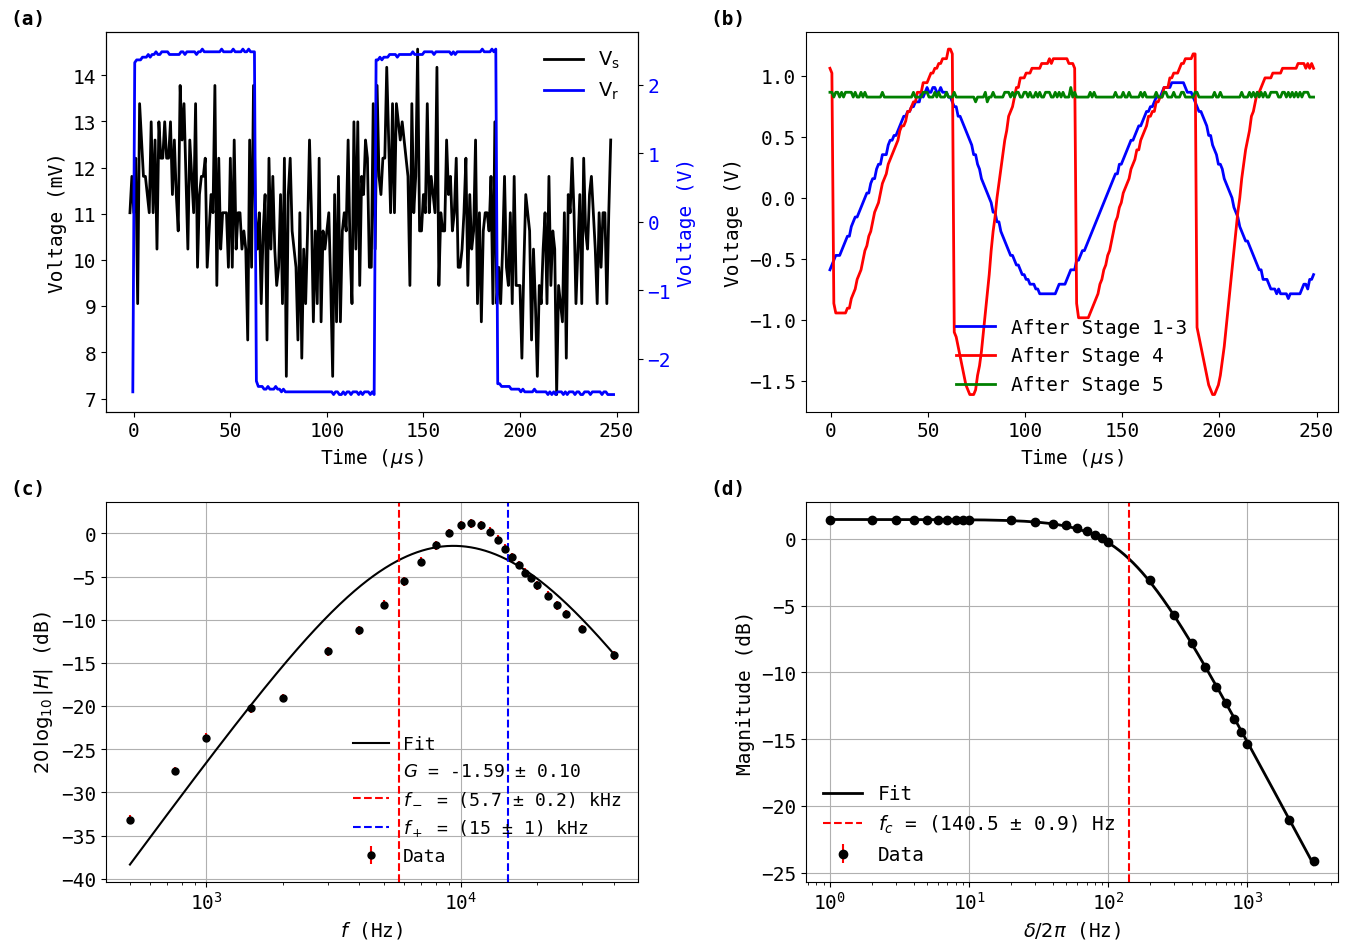

In [64]:
fig = plt.figure(figsize=(14, 10))

# Define identical axes width/height, just different left positions for col 1 vs col 2
# [left, bottom, width, height] in figure fraction
col1_left = 0.08
col2_left = 0.58
ax_width = 0.38
ax_height = 0.38
row1_bottom = 0.57
row2_bottom = 0.10

# ── (a) twin axis ──────────────────────────────────────────
ax_a = fig.add_axes([col1_left, row1_bottom, ax_width, ax_height])
line_ori = ax_a.plot(time0[:250], cha0[:250], '-', linewidth=2, color='k', label=r'$\mathrm{V_s}$')
ax_a.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax_a.set_ylabel('Voltage (mV)', fontsize=14, color='k')
ax_a.tick_params(axis='y', labelcolor='k')
ax_a.tick_params(axis='both', which='major', labelsize=14)
ax_a_twin = ax_a.twinx()
line_twin = ax_a_twin.plot(time3[:250], chb3[:250], '-', linewidth=2, color='b', label=r'$\mathrm{V_r}$')
ax_a_twin.set_ylabel('Voltage (V)', fontsize=14, color='b')
ax_a_twin.tick_params(axis='y', labelcolor='b')
ax_a_twin.tick_params(axis='both', which='major', labelsize=14)
lines = [line_ori[0], line_twin[0]]
ax_a.legend(lines, [l.get_label() for l in lines], loc='best', fontsize=14, frameon=False)
ax_a.text(-0.18, 1.02, '(a)', transform=ax_a.transAxes, fontsize=14, fontweight='bold')

# ── (b) stages 1-5 ────────────────────────────────────────
ax_b = fig.add_axes([col2_left, row1_bottom, ax_width, ax_height])
ax_b.plot(time3[:250], cha3[:250], '-', linewidth=2, color='b', label='After Stage 1-3')
ax_b.plot(time4[:250], cha4[:250], '-', linewidth=2, color='r', label='After Stage 4')
ax_b.plot(time5[:250], cha5[:250], '-', linewidth=2, color='g', label='After Stage 5')
ax_b.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax_b.set_ylabel('Voltage (V)', fontsize=14)
ax_b.tick_params(axis='both', which='major', labelsize=14)
ax_b.legend(loc='lower center', fontsize=14, frameon=False)
ax_b.text(-0.18, 1.02, '(b)', transform=ax_b.transAxes, fontsize=14, fontweight='bold')

# ── (c) stage13 fit ───────────────────────────────────────
ax_c = fig.add_axes([col1_left, row2_bottom, ax_width, ax_height])
ax_c.errorbar(freq, amp_dB, yerr=y_errs, fmt='o', ms=5, color='k', ecolor='r', label='Data')
ax_c.plot(f_linspace, func_values, linestyle='-', color='k', label='Fit')
ax_c.plot([], [], ' ', label=f'$G$ = {gain:.2f} ± {errors["G"]:.2f}')
ax_c.axvline(f_minus, color='r', linestyle='--', label=f'$f_-$ = ({round(f_minus,-2)/1000:.1f} ± {round(errors["f_minus"],-2)/1000:.1f}) kHz')
ax_c.axvline(f_plus, color='b', linestyle='--', label=f'$f_+$ = ({round(f_plus,-2)/1000:.0f} ± {round(f_plus_error,-2)/1000:.0f}) kHz')
ax_c.set_xlabel(r"$f$ (Hz)", fontsize=14)
ax_c.set_ylabel(r"$20\,\log_{10}|H|$ (dB)", fontsize=14)
ax_c.tick_params(axis='both', which='major', labelsize=14)
ax_c.set_xscale('log')
ax_c.grid(True)
ax_c.legend(loc='lower right', frameon=False, fontsize=13)
ax_c.text(-0.18, 1.02, '(c)', transform=ax_c.transAxes, fontsize=14, fontweight='bold')

# ── (d) stage5 LP fit ─────────────────────────────────────
ax_d = fig.add_axes([col2_left, row2_bottom, ax_width, ax_height])
ax_d.errorbar(freq_detuning, amp_dB_5, yerr=y_errors, fmt='o', ms=6, color='k', ecolor='r', label='Data')
ax_d.plot(f_linspace_5, func_values_5, linestyle='-', linewidth=2, color='k', label='Fit')
ax_d.axvline(f_c, color='r', linestyle='--', label=f'$f_c$ = ({f_c:.1f} ± {f_c_err:.1f}) Hz')
ax_d.set_xlabel(r"$\delta/2\pi$ (Hz)", fontsize=14)
ax_d.set_ylabel(r"Magnitude (dB)", fontsize=14)
ax_d.tick_params(axis='both', which='major', labelsize=14)
ax_d.set_xscale('log')
ax_d.grid(True)
ax_d.legend(loc='best', fontsize=14, frameon=False)
ax_d.text(-0.18, 1.02, '(d)', transform=ax_d.transAxes, fontsize=14, fontweight='bold')

plt.savefig('all_panels.pdf', dpi=600)